Signals and system expressions:

x(t) = e^{-0.2t} sin(2πt)
e(t) = x(t) - y2(t)
y(t) = ∫ e(t) dτ
y2(t) = 0.5 y(t)


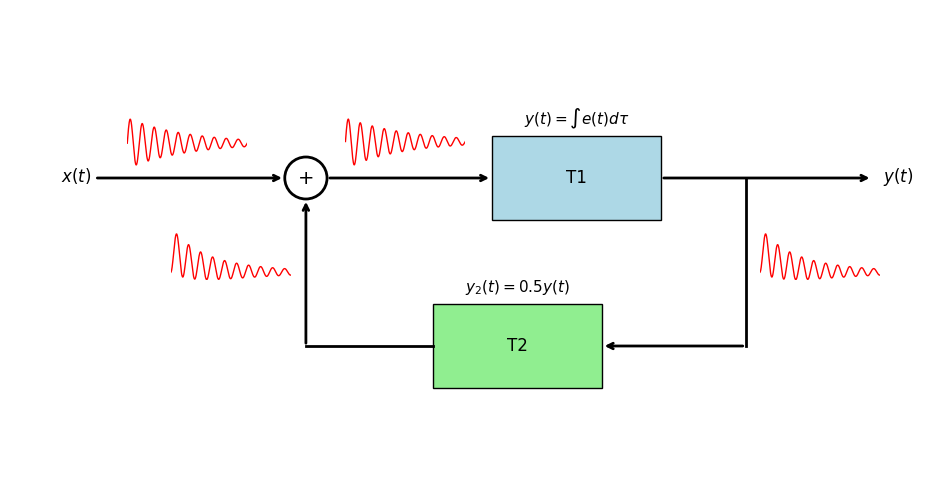

In [13]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0,10,500)
dt = t[1]-t[0]

# input signal
x = np.exp(-0.2*t)*np.sin(2*np.pi*t)

# feedback simulation
y = np.zeros_like(t)
y2 = np.zeros_like(t)
e = np.zeros_like(t)

for i in range(1,len(t)):
    e[i] = x[i] - y2[i-1]          # adder
    y[i] = y[i-1] + e[i]*dt        # T1 integrator
    y2[i] = 0.5*y[i]               # T2

print("Signals and system expressions:\n")

print("x(t) = e^{-0.2t} sin(2πt)")
print("e(t) = x(t) - y2(t)")
print("y(t) = ∫ e(t) dτ")
print("y2(t) = 0.5 y(t)")

fig, ax = plt.subplots(figsize=(12,6))

systems = [
    (5.7,3.5,'T1',r'$y(t)=\int e(t)d\tau$','lightblue'),
    (5,1.5,'T2',r'$y_2(t)=0.5y(t)$','lightgreen') ]

for x0,y0,label,eq,color in systems:
    ax.add_patch(plt.Rectangle((x0,y0),2,1, facecolor=color, edgecolor='black'))
    ax.text(x0+1,y0+0.5,label, ha='center',va='center',fontsize=12)
    ax.text(x0+1,y0+1.2,eq, ha='center',va='center',fontsize=11)

# adder
circle = plt.Circle((3.5,4), 0.25, facecolor='white', edgecolor='black', lw=2)
ax.add_patch(circle)
ax.text(3.5,4,'+', ha='center', va='center', fontsize=14)

# input arrow
ax.annotate('', xy=(3.25,4), xytext=(1,4), arrowprops=dict(arrowstyle='->',lw=2))
ax.text(0.6,3.95,r'$x(t)$',fontsize=12)

# adder to T1 (longer arrow)
ax.annotate('', xy=(5.7,4), xytext=(3.75,4), arrowprops=dict(arrowstyle='->',lw=2))

# T1 to output
ax.annotate('', xy=(10.2,4), xytext=(7.7,4), arrowprops=dict(arrowstyle='->',lw=2))
ax.text(10.32,3.95,r'$y(t)$',fontsize=12)

# feedback path (shifted with T1 output)
ax.plot([8.7,8.7],[4,2], color='black', lw=2)

ax.annotate('', xy=(7,2), xytext=(8.7,2), arrowprops=dict(arrowstyle='->',lw=2))

# T2 to adder
ax.plot([5,3.5],[2,2], color='black', lw=2)
ax.annotate('', xy=(3.5,3.75), xytext=(3.5,2), arrowprops=dict(arrowstyle='->',lw=2))

ax.set_xlim(0,11)
ax.set_ylim(0.5,6)
ax.axis('off')

# mini signal plots
signals = [ (3, x), (3.4, y2), (5, e), (8.8, y) ]
positions = [ 0.62, 0.43, 0.62, 0.43 ]

for (xc,sig),bottom in zip(signals,positions):
    width = 0.10
    height = 0.08
    left = xc/11 - width/2
    inset = fig.add_axes([left,bottom,width,height])
    inset.plot(t,sig,color='red',lw=1)
    inset.set_xlim(t[0],t[-1])
    inset.set_ylim(np.min(sig)*1.05, np.max(sig)*1.05)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.axis('off')
plt.show()